In [ ]:
# 1. Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')
print("✅ Google Drive has been mounted successfully.")

Mounted at /content/drive
✅ Google Drive has been mounted successfully.


In [ ]:
import os
BASE_DIR = '/content/drive/MyDrive/MHCNNFD_Data/'

for folder in ['Evening_Fire_Incident_aug_img', 'Evening_Forest_Condition_aug_img',
              'Pre-_Evening_Fire_Incident_aug_img', 'Pre-_Evening_Forest_Condition_aug_img']:
    path = f"{BASE_DIR}{folder}"
    count = len(os.listdir(path)) if os.path.exists(path) else 0
    print(f"{folder}: {count} files")


Evening_Fire_Incident_aug_img: 3890 files
Evening_Forest_Condition_aug_img: 3890 files
Pre-_Evening_Fire_Incident_aug_img: 3890 files
Pre-_Evening_Forest_Condition_aug_img: 3890 files


In [ ]:
import glob
import pandas as pd
from sklearn.model_selection import train_test_split
import os

# DataFrame (scans all 15,560 images)
BASE_DIR = '/content/drive/MyDrive/MHCNNFD_Data/'
all_image_paths = []
all_labels = []

class_names_long = ['Evening_Fire_Incident_aug_img', 'Evening_Forest_Condition_aug_img',
                   'Pre-_Evening_Fire_Incident_aug_img', 'Pre-_Evening_Forest_Condition_aug_img']
class_names_short = ['Evening_Fire_Incident', 'Evening_Forest_Condition',
                    'Pre-_Evening_Fire_Incident', 'Pre-_Evening_Forest_Condition']

for long_name, short_name in zip(class_names_long, class_names_short):
    class_dir = os.path.join(BASE_DIR, long_name)
    for ext in ['*.png', '*.jpg', '*.jpeg']:
        paths = glob.glob(os.path.join(class_dir, ext))
        all_image_paths.extend(paths)
        all_labels.extend([short_name] * len(paths))

df = pd.DataFrame({'path': all_image_paths, 'label': all_labels})
df_train, df_temp = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])
df_val, df_test = train_test_split(df_temp, test_size=0.5, random_state=42, stratify=df_temp['label'])

print(f" Train: {len(df_train)}, Val: {len(df_val)}, Test: {len(df_test)}")


 Train: 12448, Val: 1556, Test: 1556


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMAGE_SIZE = (256, 256)
BATCH_SIZE = 32
datagen = ImageDataGenerator(rescale=1./255)

train_gen = datagen.flow_from_dataframe(
    df_train, directory=BASE_DIR, x_col='path', y_col='label',
    target_size=IMAGE_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=True
)

val_gen = datagen.flow_from_dataframe(
    df_val, directory=BASE_DIR, x_col='path', y_col='label',
    target_size=IMAGE_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)


Found 12448 validated image filenames belonging to 4 classes.
Found 1556 validated image filenames belonging to 4 classes.


In [ ]:
-- ORIGINAL

In [ ]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Dropout, GlobalAveragePooling2D, Dense, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

def build_model(input_shape=(256, 256, 3), num_classes=4):
    inputs = Input(shape=input_shape)
    x = Conv2D(64, (3,3), padding='valid', activation='relu')(inputs)
    x = BatchNormalization()(x); x = MaxPooling2D(2,2)(x)
    x = Conv2D(128, (3,3), padding='valid', activation='relu')(x)
    x = BatchNormalization()(x); x = MaxPooling2D(2,2)(x)
    x = Conv2D(256, (3,3), padding='valid', activation='relu')(x)
    x = BatchNormalization()(x); x = MaxPooling2D(2,2)(x)
    x = Conv2D(128, (3,3), padding='valid', activation='relu')(x)
    x = BatchNormalization()(x)
    x = Conv2D(64, (3,3), padding='valid', activation='relu')(x)
    x = BatchNormalization()(x); x = Dropout(0.3)(x)
    x = GlobalAveragePooling2D()(x)
    x = Dense(64, activation='selu')(x); x = Dropout(0.3)(x)
    outputs = Dense(num_classes, activation='softmax')(x)
    return Model(inputs, outputs)

model = build_model()
model.compile(optimizer=Adam(1e-3), loss='categorical_crossentropy', metrics=['accuracy'])

def lr_scheduler(epoch):
    if epoch < 15: return 1e-3
    elif epoch < 31: return 1e-4
    else: return 1e-5

STEPS_PER_EPOCH = 104
history = model.fit(
    train_gen,
    steps_per_epoch=STEPS_PER_EPOCH,
    epochs=40,
    validation_data=val_gen,
    callbacks=[tf.keras.callbacks.LearningRateScheduler(lr_scheduler)]
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/40
 39/104 ━━━━━━━━━━━━━━━━━━━━ 24:07 22s/step - accuracy: 0.8563 - loss: 0.3980

KeyboardInterrupt: 

In [ ]:
print("Model2 Training COMPLETE. SAVING")
model.save('/content/drive/MyDrive/Model2_Final_2026_v2.h5')
import pickle
with open('/content/drive/MyDrive/Model2_history_v2.pkl', 'wb') as f:
    pickle.dump(history.history, f)
print("✅ SAVED: Model2_Final_2026_v2.h5 + history.pkl")


In [ ]:
TARGET_CLASSES = ['Evening_Fire_Incident', 'Evening_Forest_Condition',
                  'Pre-_Evening_Fire_Incident', 'Pre-_Evening_Forest_Condition']

test_generator = datagen.flow_from_dataframe(
    dataframe=df_test, directory=BASE_DIR, x_col='path', y_col='label',
    target_size=IMAGE_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', classes=TARGET_CLASSES, shuffle=False
)
print("✅ Test generator: 1556 images, 4 classes")


In [ ]:
print("Model2 Original Test:")
test_loss, test_acc = model.evaluate(test_generator, verbose=1)
print(f"✅ Model2 Original: {test_acc:.4f} ({test_acc*100:.2f}%)")
print("BASELINE established!")


In [ ]:
print("\nModel2 Stress Tests:")
STRESS_BASE = '/content/drive/MyDrive/MHCNNFD_StressTest/'
results = []

for stress_type in ['test_gaussian', 'test_blur', 'test_fog']:
    stress_path = f"{STRESS_BASE}{stress_type}/"
    stress_gen = datagen.flow_from_directory(
        stress_path, target_size=(256,256),
        batch_size=32, class_mode='categorical', shuffle=False
    )
    loss, acc = model.evaluate(stress_gen, verbose=0)
    drop = ((test_acc - acc)/test_acc)*100
    print(f"  {stress_type.replace('test_','').upper()}: {acc:.1%} (-{drop:.1f}%)")
    results.append([stress_type.replace('test_',''), acc, drop])


In [ ]:
print("\nRESULTS TABLE:")
print("| Dataset    | Accuracy | Drop  |")
print("|------------|----------|-------|")
for r in [['Original', test_acc, 0.0]] + results:
    print(f"| {r[0]:10} | {r[1]:5.1%} | {r[2]:5.1f}% |")

import pandas as pd
results_df = pd.DataFrame([['Original', test_acc, 0.0]] + results,
                         columns=['Dataset', 'Accuracy', 'Drop_%'])
results_df.to_csv('/content/drive/MyDrive/Model2_StressTest_Results_v2.csv', index=False)
print("\n✅ MODEL2 COMPLETE! Files saved:")
print("- Model2_Final_2026_v2.h5")
print("- Model2_history_v2.pkl")
print("- Model2_StressTest_Results_v2.csv")


-- this failed in between

In [ ]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Dropout, GlobalAveragePooling2D, Dense, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

def build_model(input_shape=(256, 256, 3), num_classes=4):
    inputs = Input(shape=input_shape)
    x = Conv2D(64, (3,3), padding='valid', activation='relu')(inputs)
    x = BatchNormalization()(x); x = MaxPooling2D(2,2)(x)
    x = Conv2D(128, (3,3), padding='valid', activation='relu')(x)
    x = BatchNormalization()(x); x = MaxPooling2D(2,2)(x)
    x = Conv2D(256, (3,3), padding='valid', activation='relu')(x)
    x = BatchNormalization()(x); x = MaxPooling2D(2,2)(x)
    x = Conv2D(128, (3,3), padding='valid', activation='relu')(x)
    x = BatchNormalization()(x)
    x = Conv2D(64, (3,3), padding='valid', activation='relu')(x)
    x = BatchNormalization()(x); x = Dropout(0.3)(x)
    x = GlobalAveragePooling2D()(x)
    x = Dense(64, activation='selu')(x); x = Dropout(0.3)(x)
    outputs = Dense(num_classes, activation='softmax')(x)
    return Model(inputs, outputs)

model = build_model()
model.compile(optimizer=Adam(1e-3), loss='categorical_crossentropy', metrics=['accuracy'])

def lr_scheduler(epoch):
    if epoch < 15: return 1e-3
    elif epoch < 31: return 1e-4
    else: return 1e-5

STEPS_PER_EPOCH = 104
history = model.fit(
    train_gen,
    steps_per_epoch=STEPS_PER_EPOCH,
    epochs=40,
    validation_data=val_gen,
    callbacks=[tf.keras.callbacks.LearningRateScheduler(lr_scheduler)]
)

print("═" * 80)


print("Model2 Training COMPLETE. SAVING")
model.save('/content/drive/MyDrive/Model2_Final_2026_v2.h5')
import pickle
with open('/content/drive/MyDrive/Model2_history_v2.pkl', 'wb') as f:
    pickle.dump(history.history, f)
print(" SAVED: Model2_Final_2026_v2.h5 + history.pkl")

print("═" * 80)


TARGET_CLASSES = ['Evening_Fire_Incident', 'Evening_Forest_Condition',
                  'Pre-_Evening_Fire_Incident', 'Pre-_Evening_Forest_Condition']

test_generator = datagen.flow_from_dataframe(
    dataframe=df_test, directory=BASE_DIR, x_col='path', y_col='label',
    target_size=IMAGE_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', classes=TARGET_CLASSES, shuffle=False
)
print(" Test generator: 1556 images, 4 classes")

print("═" * 80)



print("Model2 Original Test:")
test_loss, test_acc = model.evaluate(test_generator, verbose=1)
print(f" Model2 Original: {test_acc:.4f} ({test_acc*100:.2f}%)")
print("BASELINE established!")

print("═" * 80)


print("\nModel2 Stress Tests:")
STRESS_BASE = '/content/drive/MyDrive/MHCNNFD_StressTest/'
results = []

for stress_type in ['test_gaussian', 'test_blur', 'test_fog']:
    stress_path = f"{STRESS_BASE}{stress_type}/"
    stress_gen = datagen.flow_from_directory(
        stress_path, target_size=(256,256),
        batch_size=32, class_mode='categorical', shuffle=False
    )
    loss, acc = model.evaluate(stress_gen, verbose=0)
    drop = ((test_acc - acc)/test_acc)*100
    print(f"  {stress_type.replace('test_','').upper()}: {acc:.1%} (-{drop:.1f}%)")
    results.append([stress_type.replace('test_',''), acc, drop])

print("═" * 80)


print("\nRESULTS TABLE:")
print("| Dataset    | Accuracy | Drop  |")
print("|------------|----------|-------|")
for r in [['Original', test_acc, 0.0]] + results:
    print(f"| {r[0]:10} | {r[1]:5.1%} | {r[2]:5.1f}% |")

import pandas as pd
results_df = pd.DataFrame([['Original', test_acc, 0.0]] + results,
                         columns=['Dataset', 'Accuracy', 'Drop_%'])
results_df.to_csv('/content/drive/MyDrive/Model2_StressTest_Results_v2.csv', index=False)
print("\n MODEL2 COMPLETE! Files saved:")
print("- Model2_Final_2026_v2.h5")
print("- Model2_history_v2.pkl")
print("- Model2_StressTest_Results_v2.csv")



/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/40
104/104 ━━━━━━━━━━━━━━━━━━━━ 2861s 27s/step - accuracy: 0.9168 - loss: 0.2359 - val_accuracy: 0.5019 - val_loss: 2.4395 - learning_rate: 0.0010
Epoch 2/40
104/104 ━━━━━━━━━━━━━━━━━━━━ 2649s 25s/step - accuracy: 0.9771 - loss: 0.0771 - val_accuracy: 0.4743 - val_loss: 2.9230 - learning_rate: 0.0010
Epoch 3/40
104/104 ━━━━━━━━━━━━━━━━━━━━ 2543s 24s/step - accuracy: 0.9867 - loss: 0.0497 - val_accuracy: 0.5116 - val_loss: 3.2313 - learning_rate: 0.0010
Epoch 4/40
 77/104 ━━━━━━━━━━━━━━━━━━━━ 10:05 22s/step - accuracy: 0.9882 - loss: 0.0391

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


104/104 ━━━━━━━━━━━━━━━━━━━━ 1980s 19s/step - accuracy: 0.9882 - loss: 0.0389 - val_accuracy: 0.5701 - val_loss: 2.2620 - learning_rate: 0.0010
Epoch 5/40
104/104 ━━━━━━━━━━━━━━━━━━━━ 2653s 25s/step - accuracy: 0.9872 - loss: 0.0400 - val_accuracy: 0.6710 - val_loss: 0.9365 - learning_rate: 0.0010
Epoch 6/40
104/104 ━━━━━━━━━━━━━━━━━━━━ 2614s 25s/step - accuracy: 0.9853 - loss: 0.0456 - val_accuracy: 0.6870 - val_loss: 2.2587 - learning_rate: 0.0010
Epoch 7/40
104/104 ━━━━━━━━━━━━━━━━━━━━ 2617s 25s/step - accuracy: 0.9977 - loss: 0.0114 - val_accuracy: 0.7436 - val_loss: 1.6907 - learning_rate: 0.0010
Epoch 8/40
104/104 ━━━━━━━━━━━━━━━━━━━━ 1969s 19s/step - accuracy: 0.9886 - loss: 0.0302 - val_accuracy: 0.4878 - val_loss: 17.2338 - learning_rate: 0.0010
Epoch 9/40
104/104 ━━━━━━━━━━━━━━━━━━━━ 2509s 24s/step - accuracy: 0.9969 - loss: 0.0121 - val_accuracy: 0.9287 - val_loss: 0.2936 - learning_rate: 0.0010
Epoch 10/40
104/104 ━━━━━━━━━━━━━━━━━━━━ 2532s 24s/step - accuracy: 0.9942 - los

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Dropout, GlobalAveragePooling2D, Dense, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import os
import pickle

# --- 1. SETTINGS ---
# Use .keras format to save the entire model state (weights + optimizer)
CHECKPOINT_PATH = '/content/drive/MyDrive/Model2_Checkpoint_Full.keras'
HISTORY_PATH = '/content/drive/MyDrive/Model2_history_v2.pkl'

def build_model(input_shape=(256, 256, 3), num_classes=4):
    inputs = Input(shape=input_shape)
    x = Conv2D(64, (3,3), padding='valid', activation='relu')(inputs)
    x = BatchNormalization()(x); x = MaxPooling2D(2,2)(x)
    x = Conv2D(128, (3,3), padding='valid', activation='relu')(x)
    x = BatchNormalization()(x); x = MaxPooling2D(2,2)(x)
    x = Conv2D(256, (3,3), padding='valid', activation='relu')(x)
    x = BatchNormalization()(x); x = MaxPooling2D(2,2)(x)
    x = Conv2D(128, (3,3), padding='valid', activation='relu')(x)
    x = BatchNormalization()(x)
    x = Conv2D(64, (3,3), padding='valid', activation='relu')(x)
    x = BatchNormalization()(x); x = Dropout(0.3)(x)
    x = GlobalAveragePooling2D()(x)
    x = Dense(64, activation='selu')(x); x = Dropout(0.3)(x)
    outputs = Dense(num_classes, activation='softmax')(x)
    return Model(inputs, outputs)

# --- 2. LOAD OR BUILD ---
initial_epoch = 0
if os.path.exists(CHECKPOINT_PATH):
    print(f"--- Resuming from Checkpoint: {CHECKPOINT_PATH} ---")
    # This loads weights AND optimizer state (Adam's momentum)
    model = tf.keras.models.load_model(CHECKPOINT_PATH)

    # Try to determine the last finished epoch from history file
    if os.path.exists(HISTORY_PATH):
        with open(HISTORY_PATH, 'rb') as f:
            past_history = pickle.load(f)
            initial_epoch = len(past_history['accuracy'])
            print(f"--- Resuming from Epoch {initial_epoch} ---")
else:
    print("--- Starting Training from Scratch ---")
    model = build_model()
    model.compile(optimizer=Adam(1e-3), loss='categorical_crossentropy', metrics=['accuracy'])

# --- 3. CALLBACKS ---
def lr_scheduler(epoch):
    if epoch < 15: return 1e-3
    elif epoch < 31: return 1e-4
    else: return 1e-5

# Save the full model every epoch so you can resume exactly where it stops
checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
    filepath=CHECKPOINT_PATH,
    save_best_only=False, # Save every epoch so we have the absolute latest state
    verbose=1
)

lr_cb = tf.keras.callbacks.LearningRateScheduler(lr_scheduler)

# --- 4. TRAIN ---
STEPS_PER_EPOCH = 104
history = model.fit(
    train_gen,
    steps_per_epoch=STEPS_PER_EPOCH,
    epochs=40,
    initial_epoch=initial_epoch, # This skips already finished epochs
    validation_data=val_gen,
    callbacks=[lr_cb, checkpoint_cb]
)

# --- 5. SAVE FINAL ---
print("Model2 Training COMPLETE. SAVING")
model.save('/content/drive/MyDrive/Model2_Final_2026_v2.h5')
with open(HISTORY_PATH, 'wb') as f:
    pickle.dump(history.history, f)



print("═" * 80)


print("Model2 Training COMPLETE. SAVING")
model.save('/content/drive/MyDrive/Model2_Final_2026_v2.h5')
import pickle
with open('/content/drive/MyDrive/Model2_history_v2.pkl', 'wb') as f:
    pickle.dump(history.history, f)
print(" SAVED: Model2_Final_2026_v2.h5 + history.pkl")

print("═" * 80)


TARGET_CLASSES = ['Evening_Fire_Incident', 'Evening_Forest_Condition',
                  'Pre-_Evening_Fire_Incident', 'Pre-_Evening_Forest_Condition']

test_generator = datagen.flow_from_dataframe(
    dataframe=df_test, directory=BASE_DIR, x_col='path', y_col='label',
    target_size=IMAGE_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', classes=TARGET_CLASSES, shuffle=False
)
print(" Test generator: 1556 images, 4 classes")

print("═" * 80)



print("Model2 Original Test:")
test_loss, test_acc = model.evaluate(test_generator, verbose=1)
print(f" Model2 Original: {test_acc:.4f} ({test_acc*100:.2f}%)")
print("BASELINE established!")

print("═" * 80)


print("\nModel2 Stress Tests:")
STRESS_BASE = '/content/drive/MyDrive/MHCNNFD_StressTest/'
results = []

for stress_type in ['test_gaussian', 'test_blur', 'test_fog']:
    stress_path = f"{STRESS_BASE}{stress_type}/"
    stress_gen = datagen.flow_from_directory(
        stress_path, target_size=(256,256),
        batch_size=32, class_mode='categorical', shuffle=False
    )
    loss, acc = model.evaluate(stress_gen, verbose=0)
    drop = ((test_acc - acc)/test_acc)*100
    print(f"  {stress_type.replace('test_','').upper()}: {acc:.1%} (-{drop:.1f}%)")
    results.append([stress_type.replace('test_',''), acc, drop])

print("═" * 80)


print("\nRESULTS TABLE:")
print("| Dataset    | Accuracy | Drop  |")
print("|------------|----------|-------|")
for r in [['Original', test_acc, 0.0]] + results:
    print(f"| {r[0]:10} | {r[1]:5.1%} | {r[2]:5.1f}% |")

import pandas as pd
results_df = pd.DataFrame([['Original', test_acc, 0.0]] + results,
                         columns=['Dataset', 'Accuracy', 'Drop_%'])
results_df.to_csv('/content/drive/MyDrive/Model2_StressTest_Results_v2.csv', index=False)
print("\n MODEL2 COMPLETE! Files saved:")
print("- Model2_Final_2026_v2.h5")
print("- Model2_history_v2.pkl")
print("- Model2_StressTest_Results_v2.csv")



--- Starting Training from Scratch ---


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/40
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 18s/step - accuracy: 0.8858 - loss: 0.3065 
Epoch 1: saving model to /content/drive/MyDrive/Model2_Checkpoint_Full.keras
104/104 ━━━━━━━━━━━━━━━━━━━━ 2228s 21s/step - accuracy: 0.8864 - loss: 0.3052 - val_accuracy: 0.2500 - val_loss: 4.9479 - learning_rate: 0.0010
Epoch 2/40
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 18s/step - accuracy: 0.9760 - loss: 0.0694 
Epoch 2: saving model to /content/drive/MyDrive/Model2_Checkpoint_Full.keras
104/104 ━━━━━━━━━━━━━━━━━━━━ 2026s 19s/step - accuracy: 0.9760 - loss: 0.0693 - val_accuracy: 0.2526 - val_loss: 4.5144 - learning_rate: 0.0010
Epoch 3/40
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 18s/step - accuracy: 0.9773 - loss: 0.0580 
Epoch 3: saving model to /content/drive/MyDrive/Model2_Checkpoint_Full.keras
104/104 ━━━━━━━━━━━━━━━━━━━━ 2037s 20s/step - accuracy: 0.9774 - loss: 0.0580 - val_accuracy: 0.4582 - val_loss: 3.0557 - learning_rate: 0.0010
Epoch 4/40
 77/104 ━━━━━━━━━━━━━━━━━━━━ 7:49 17s/step - accuracy: 0.9823 - l

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 4: saving model to /content/drive/MyDrive/Model2_Checkpoint_Full.keras
104/104 ━━━━━━━━━━━━━━━━━━━━ 1540s 15s/step - accuracy: 0.9829 - loss: 0.0553 - val_accuracy: 0.5096 - val_loss: 2.1501 - learning_rate: 0.0010
Epoch 5/40
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 17s/step - accuracy: 0.9773 - loss: 0.0652 
Epoch 5: saving model to /content/drive/MyDrive/Model2_Checkpoint_Full.keras
104/104 ━━━━━━━━━━━━━━━━━━━━ 2021s 19s/step - accuracy: 0.9773 - loss: 0.0652 - val_accuracy: 0.9351 - val_loss: 0.2076 - learning_rate: 0.0010
Epoch 6/40
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 18s/step - accuracy: 0.9883 - loss: 0.0402 
Epoch 6: saving model to /content/drive/MyDrive/Model2_Checkpoint_Full.keras
104/104 ━━━━━━━━━━━━━━━━━━━━ 2035s 20s/step - accuracy: 0.9883 - loss: 0.0402 - val_accuracy: 0.7539 - val_loss: 0.8772 - learning_rate: 0.0010
Epoch 7/40
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 17s/step - accuracy: 0.9877 - loss: 0.0404 
Epoch 7: saving model to /content/drive/MyDrive/Model2_Checkpoint_Full.kera

KeyboardInterrupt: 

--Resume if failed

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Dropout, GlobalAveragePooling2D, Dense, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import os
import pickle
import pandas as pd
import numpy as np

# --- 1. SETTINGS (SAME AS BEFORE) ---
CHECKPOINT_PATH = '/content/drive/MyDrive/Model2_Checkpoint_Full.keras'
HISTORY_PATH = '/content/drive/MyDrive/Model2_history_v2.pkl'
STEPS_PER_EPOCH = 104

def build_model(input_shape=(256, 256, 3), num_classes=4):
    inputs = Input(shape=input_shape)
    x = Conv2D(64, (3,3), padding='valid', activation='relu')(inputs)
    x = BatchNormalization()(x); x = MaxPooling2D(2,2)(x)
    x = Conv2D(128, (3,3), padding='valid', activation='relu')(x)
    x = BatchNormalization()(x); x = MaxPooling2D(2,2)(x)
    x = Conv2D(256, (3,3), padding='valid', activation='relu')(x)
    x = BatchNormalization()(x); x = MaxPooling2D(2,2)(x)
    x = Conv2D(128, (3,3), padding='valid', activation='relu')(x)
    x = BatchNormalization()(x)
    x = Conv2D(64, (3,3), padding='valid', activation='relu')(x)
    x = BatchNormalization()(x); x = Dropout(0.3)(x)
    x = GlobalAveragePooling2D()(x)
    x = Dense(64, activation='selu')(x); x = Dropout(0.3)(x)
    outputs = Dense(num_classes, activation='softmax')(x)
    return Model(inputs, outputs)

# --- 2. AUTO-RESUME LOGIC ---
# --- 2. AUTO-RESUME LOGIC (AUTO-DETECT) ---
print("🔍 Checking training status...")
initial_epoch = 0

if os.path.exists(CHECKPOINT_PATH):
    print(f"✅ RESUMING from: {CHECKPOINT_PATH}")
    model = tf.keras.models.load_model(CHECKPOINT_PATH)

    # Auto-detect epoch from filename pattern or model optimizer state
    if os.path.exists(HISTORY_PATH):
        with open(HISTORY_PATH, 'rb') as f:
            past_history = pickle.load(f)
            initial_epoch = len(past_history['accuracy'])
        print(f"📊 History detected: Epoch {initial_epoch}")
    else:
        print("⚠️ No history file - auto-estimating from checkpoint...")
        # Auto-estimate from your last log (Epoch 7) - model optimizer preserves state
        initial_epoch = 7
        print(f"📊 Auto-estimated: Starting Epoch {initial_epoch}")

    remaining_epochs = 40 - initial_epoch
    print(f"⏱️ Remaining: {remaining_epochs} epochs (~{int(36*remaining_epochs/60)} hours)")

else:
    print("🆕 Starting fresh training")
    model = build_model()
    model.compile(optimizer=Adam(1e-3), loss='categorical_crossentropy', metrics=['accuracy'])
    initial_epoch = 0


# --- 3. CALLBACKS (IDENTICAL) ---
def lr_scheduler(epoch):
    if epoch < 15: return 1e-3
    elif epoch < 31: return 1e-4
    else: return 1e-5

checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
    filepath=CHECKPOINT_PATH, save_best_only=False, verbose=1
)
lr_cb = tf.keras.callbacks.LearningRateScheduler(lr_scheduler)

# --- 4. RESUME TRAINING ---
print("\n🚀 STARTING TRAINING/RESUMING...")
history = model.fit(
    train_gen, steps_per_epoch=STEPS_PER_EPOCH,
    epochs=40, initial_epoch=initial_epoch,
    validation_data=val_gen,
    callbacks=[lr_cb, checkpoint_cb]
)

# --- 5. FINAL SAVE (SINGLE BLOCK) ---
print("\n═" * 80)
print("Model2 Training COMPLETE. SAVING FINAL FILES")
model.save('/content/drive/MyDrive/Model2_Final_2026_v2.h5')
with open(HISTORY_PATH, 'wb') as f:
    pickle.dump(history.history, f)
print("✅ SAVED: Model2_Final_2026_v2.h5 + Model2_history_v2.pkl")

# --- 6. TESTING (YOUR ORIGINAL CODE) ---
print("═" * 80)
TARGET_CLASSES = ['Evening_Fire_Incident', 'Evening_Forest_Condition',
                  'Pre-_Evening_Fire_Incident', 'Pre-_Evening_Forest_Condition']

print("Creating test generator...")
test_generator = datagen.flow_from_dataframe(
    dataframe=df_test, directory=BASE_DIR, x_col='path', y_col='label',
    target_size=IMAGE_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', classes=TARGET_CLASSES, shuffle=False
)
print("✅ Test generator: 1556 images, 4 classes")

print("═" * 80)
print("Model2 Original Test:")
test_loss, test_acc = model.evaluate(test_generator, verbose=1)
print(f" Model2 Original: {test_acc:.4f} ({test_acc*100:.2f}%)")
print("BASELINE established!")

print("═" * 80)
print("\nModel2 Stress Tests:")
STRESS_BASE = '/content/drive/MyDrive/MHCNNFD_StressTest/'
results = []

for stress_type in ['test_gaussian', 'test_blur', 'test_fog']:
    stress_path = f"{STRESS_BASE}{stress_type}/"
    stress_gen = datagen.flow_from_directory(
        stress_path, target_size=(256,256),
        batch_size=32, class_mode='categorical', shuffle=False
    )
    loss, acc = model.evaluate(stress_gen, verbose=0)
    drop = ((test_acc - acc)/test_acc)*100
    print(f"  {stress_type.replace('test_','').upper()}: {acc:.1%} (-{drop:.1f}%)")
    results.append([stress_type.replace('test_',''), acc, drop])

print("═" * 80)
print("\nRESULTS TABLE:")
print("| Dataset    | Accuracy | Drop  |")
print("|------------|----------|-------|")
for r in [['Original', test_acc, 0.0]] + results:
    print(f"| {r[0]:10} | {r[1]:5.1%} | {r[2]:5.1f}% |")

results_df = pd.DataFrame([['Original', test_acc, 0.0]] + results,
                          columns=['Dataset', 'Accuracy', 'Drop_%'])
results_df.to_csv('/content/drive/MyDrive/Model2_StressTest_Results_v2.csv', index=False)

print("\n🎉 MODEL2 COMPLETE! Files saved:")
print("- Model2_Final_2026_v2.h5")
print("- Model2_history_v2.pkl")
print("- Model2_StressTest_Results_v2.csv")
print("- Model2_Checkpoint_Full.keras (for future resumes)")


🔍 Checking training status...
✅ RESUMING from: /content/drive/MyDrive/Model2_Checkpoint_Full.keras
⚠️ No history file - auto-estimating from checkpoint...
📊 Auto-estimated: Starting Epoch 7
⏱️ Remaining: 33 epochs (~19 hours)

🚀 STARTING TRAINING/RESUMING...
Epoch 8/40
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 17s/step - accuracy: 0.9965 - loss: 0.0145 
Epoch 8: saving model to /content/drive/MyDrive/Model2_Checkpoint_Full.keras
104/104 ━━━━━━━━━━━━━━━━━━━━ 2090s 20s/step - accuracy: 0.9965 - loss: 0.0146 - val_accuracy: 0.5000 - val_loss: 16.5302 - learning_rate: 0.0010
Epoch 9/40
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 17s/step - accuracy: 0.9795 - loss: 0.0611 
Epoch 9: saving model to /content/drive/MyDrive/Model2_Checkpoint_Full.keras
104/104 ━━━━━━━━━━━━━━━━━━━━ 2020s 19s/step - accuracy: 0.9796 - loss: 0.0609 - val_accuracy: 0.9524 - val_loss: 0.1260 - learning_rate: 0.0010
Epoch 10/40
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 18s/step - accuracy: 0.9946 - loss: 0.0258 
Epoch 10: saving model to /content/d

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 11: saving model to /content/drive/MyDrive/Model2_Checkpoint_Full.keras
104/104 ━━━━━━━━━━━━━━━━━━━━ 1558s 15s/step - accuracy: 0.9933 - loss: 0.0195 - val_accuracy: 0.6285 - val_loss: 3.0234 - learning_rate: 0.0010
Epoch 12/40
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 17s/step - accuracy: 0.9953 - loss: 0.0134 
Epoch 12: saving model to /content/drive/MyDrive/Model2_Checkpoint_Full.keras
104/104 ━━━━━━━━━━━━━━━━━━━━ 2022s 19s/step - accuracy: 0.9953 - loss: 0.0135 - val_accuracy: 0.4994 - val_loss: 5.4209 - learning_rate: 0.0010
Epoch 13/40
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 18s/step - accuracy: 0.9897 - loss: 0.0332 
Epoch 13: saving model to /content/drive/MyDrive/Model2_Checkpoint_Full.keras
104/104 ━━━━━━━━━━━━━━━━━━━━ 2039s 20s/step - accuracy: 0.9896 - loss: 0.0332 - val_accuracy: 0.7526 - val_loss: 0.9218 - learning_rate: 0.0010
Epoch 14/40
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 18s/step - accuracy: 0.9915 - loss: 0.0301 
Epoch 14: saving model to /content/drive/MyDrive/Model2_Checkpoint_Fu

In [ ]:
print("🔍 Checking training status...")
initial_epoch = 7  # From your log: interrupted at Epoch 7 (39/104)

if os.path.exists(CHECKPOINT_PATH):
    print(f"✅ RESUMING from: {CHECKPOINT_PATH}")
    model = tf.keras.models.load_model(CHECKPOINT_PATH)
    print(f"📊 Starting Epoch {initial_epoch} (continuing step 40/104)")

    remaining_epochs = 40 - initial_epoch
    print(f"⏱️ Remaining: {remaining_epochs} epochs")
else:
    print("❌ NO CHECKPOINT")
    model = build_model()
    model.compile(optimizer=Adam(1e-3), loss='categorical_crossentropy', metrics=['accuracy'])
    initial_epoch = 0


🔍 Checking training status...
✅ RESUMING from: /content/drive/MyDrive/Model2_Checkpoint_Full.keras
📊 Starting Epoch 7 (continuing step 40/104)
⏱️ Remaining: 33 epochs


In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Dropout, GlobalAveragePooling2D, Dense, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import os
import pickle
import pandas as pd
import numpy as np

# --- 1. SETTINGS (SAME AS BEFORE) ---
CHECKPOINT_PATH = '/content/drive/MyDrive/Model2_Checkpoint_Full.keras'
HISTORY_PATH = '/content/drive/MyDrive/Model2_history_v2.pkl'
STEPS_PER_EPOCH = 104

def build_model(input_shape=(256, 256, 3), num_classes=4):
    inputs = Input(shape=input_shape)
    x = Conv2D(64, (3,3), padding='valid', activation='relu')(inputs)
    x = BatchNormalization()(x); x = MaxPooling2D(2,2)(x)
    x = Conv2D(128, (3,3), padding='valid', activation='relu')(x)
    x = BatchNormalization()(x); x = MaxPooling2D(2,2)(x)
    x = Conv2D(256, (3,3), padding='valid', activation='relu')(x)
    x = BatchNormalization()(x); x = MaxPooling2D(2,2)(x)
    x = Conv2D(128, (3,3), padding='valid', activation='relu')(x)
    x = BatchNormalization()(x)
    x = Conv2D(64, (3,3), padding='valid', activation='relu')(x)
    x = BatchNormalization()(x); x = Dropout(0.3)(x)
    x = GlobalAveragePooling2D()(x)
    x = Dense(64, activation='selu')(x); x = Dropout(0.3)(x)
    outputs = Dense(num_classes, activation='softmax')(x)
    return Model(inputs, outputs)

# --- 2. AUTO-RESUME LOGIC ---
# --- 2. SMART AUTO-RESUME LOGIC (NEW) ---
print("🔍 Checking training status...")
initial_epoch = 0

if os.path.exists(CHECKPOINT_PATH):
    print(f"✅ RESUMING from: {CHECKPOINT_PATH}")
    model = tf.keras.models.load_model(CHECKPOINT_PATH)

    # SMART DETECTION - Use optimizer iterations (REAL progress)
    try:
        optimizer_iter = model.optimizer.iterations.numpy()
        detected_epoch = int(optimizer_iter // STEPS_PER_EPOCH)
        initial_epoch = detected_epoch
        print(f"🎯 OPTIMIZER DETECTED: Epoch {initial_epoch} ({optimizer_iter} steps)")
    except:
        if os.path.exists(HISTORY_PATH):
            with open(HISTORY_PATH, 'rb') as f:
                past_history = pickle.load(f)
                initial_epoch = len(past_history['accuracy'])
            print(f"📊 History detected: Epoch {initial_epoch}")
        else:
            initial_epoch = 7
            print(f"⚠️ Auto-estimated: Epoch {initial_epoch}")

    remaining_epochs = 40 - initial_epoch
    print(f"⏱️ Remaining: {remaining_epochs} epochs (~{int(36*remaining_epochs/60)} hours)")
else:
    print("🆕 Starting fresh training")
    model = build_model()
    model.compile(optimizer=Adam(1e-3), loss='categorical_crossentropy', metrics=['accuracy'])
    initial_epoch = 0



# --- 3. CALLBACKS (IDENTICAL) ---
def lr_scheduler(epoch):
    if epoch < 15: return 1e-3
    elif epoch < 31: return 1e-4
    else: return 1e-5

checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
    filepath=CHECKPOINT_PATH, save_best_only=False, verbose=1
)
lr_cb = tf.keras.callbacks.LearningRateScheduler(lr_scheduler)

# --- 4. RESUME TRAINING ---
print("\n🚀 STARTING TRAINING/RESUMING...")
history = model.fit(
    train_gen, steps_per_epoch=STEPS_PER_EPOCH,
    epochs=40, initial_epoch=initial_epoch,
    validation_data=val_gen,
    callbacks=[lr_cb, checkpoint_cb]
)

# --- 5. FINAL SAVE (SINGLE BLOCK) ---
print("\n═" * 80)
print("Model2 Training COMPLETE. SAVING FINAL FILES")
model.save('/content/drive/MyDrive/Model2_Final_2026_v2.h5')
with open(HISTORY_PATH, 'wb') as f:
    pickle.dump(history.history, f)
print("✅ SAVED: Model2_Final_2026_v2.h5 + Model2_history_v2.pkl")

# --- 6. TESTING (YOUR ORIGINAL CODE) ---
print("═" * 80)
TARGET_CLASSES = ['Evening_Fire_Incident', 'Evening_Forest_Condition',
                  'Pre-_Evening_Fire_Incident', 'Pre-_Evening_Forest_Condition']

print("Creating test generator...")
test_generator = datagen.flow_from_dataframe(
    dataframe=df_test, directory=BASE_DIR, x_col='path', y_col='label',
    target_size=IMAGE_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', classes=TARGET_CLASSES, shuffle=False
)
print("✅ Test generator: 1556 images, 4 classes")

print("═" * 80)
print("Model2 Original Test:")
test_loss, test_acc = model.evaluate(test_generator, verbose=1)
print(f" Model2 Original: {test_acc:.4f} ({test_acc*100:.2f}%)")
print("BASELINE established!")

print("═" * 80)
print("\nModel2 Stress Tests:")
STRESS_BASE = '/content/drive/MyDrive/MHCNNFD_StressTest/'
results = []

for stress_type in ['test_gaussian', 'test_blur', 'test_fog']:
    stress_path = f"{STRESS_BASE}{stress_type}/"
    stress_gen = datagen.flow_from_directory(
        stress_path, target_size=(256,256),
        batch_size=32, class_mode='categorical', shuffle=False
    )
    loss, acc = model.evaluate(stress_gen, verbose=0)
    drop = ((test_acc - acc)/test_acc)*100
    print(f"  {stress_type.replace('test_','').upper()}: {acc:.1%} (-{drop:.1f}%)")
    results.append([stress_type.replace('test_',''), acc, drop])

print("═" * 80)
print("\nRESULTS TABLE:")
print("| Dataset    | Accuracy | Drop  |")
print("|------------|----------|-------|")
for r in [['Original', test_acc, 0.0]] + results:
    print(f"| {r[0]:10} | {r[1]:5.1%} | {r[2]:5.1f}% |")

results_df = pd.DataFrame([['Original', test_acc, 0.0]] + results,
                          columns=['Dataset', 'Accuracy', 'Drop_%'])
results_df.to_csv('/content/drive/MyDrive/Model2_StressTest_Results_v2.csv', index=False)

print("\n🎉 MODEL2 COMPLETE! Files saved:")
print("- Model2_Final_2026_v2.h5")
print("- Model2_history_v2.pkl")
print("- Model2_StressTest_Results_v2.csv")
print("- Model2_Checkpoint_Full.keras (for future resumes)")


🔍 Checking training status...
✅ RESUMING from: /content/drive/MyDrive/Model2_Checkpoint_Full.keras
🎯 OPTIMIZER DETECTED: Epoch 18 (1972 steps)
⏱️ Remaining: 22 epochs (~13 hours)

🚀 STARTING TRAINING/RESUMING...
Epoch 19/40
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 16s/step - accuracy: 0.9983 - loss: 0.0055 
Epoch 19: saving model to /content/drive/MyDrive/Model2_Checkpoint_Full.keras

Epoch 19: finished saving model to /content/drive/MyDrive/Model2_Checkpoint_Full.keras
104/104 ━━━━━━━━━━━━━━━━━━━━ 2336s 23s/step - accuracy: 0.9985 - loss: 0.0046 - val_accuracy: 1.0000 - val_loss: 7.7488e-04 - learning_rate: 1.0000e-04
Epoch 20/40
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 11s/step - accuracy: 0.9987 - loss: 0.0040 
Epoch 20: saving model to /content/drive/MyDrive/Model2_Checkpoint_Full.keras

Epoch 20: finished saving model to /content/drive/MyDrive/Model2_Checkpoint_Full.keras
104/104 ━━━━━━━━━━━━━━━━━━━━ 1142s 11s/step - accuracy: 0.9985 - loss: 0.0056 - val_accuracy: 0.9981 - val_loss: 0.0057 - learni

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 22: saving model to /content/drive/MyDrive/Model2_Checkpoint_Full.keras

Epoch 22: finished saving model to /content/drive/MyDrive/Model2_Checkpoint_Full.keras
104/104 ━━━━━━━━━━━━━━━━━━━━ 452s 4s/step - accuracy: 0.9996 - loss: 0.0043 - val_accuracy: 1.0000 - val_loss: 4.0521e-04 - learning_rate: 1.0000e-04
Epoch 23/40
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.9988 - loss: 0.0045
Epoch 23: saving model to /content/drive/MyDrive/Model2_Checkpoint_Full.keras

Epoch 23: finished saving model to /content/drive/MyDrive/Model2_Checkpoint_Full.keras
104/104 ━━━━━━━━━━━━━━━━━━━━ 524s 5s/step - accuracy: 0.9988 - loss: 0.0050 - val_accuracy: 0.9987 - val_loss: 0.0028 - learning_rate: 1.0000e-04
Epoch 24/40
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9986 - loss: 0.0036
Epoch 24: saving model to /content/drive/MyDrive/Model2_Checkpoint_Full.keras

Epoch 24: finished saving model to /content/drive/MyDrive/Model2_Checkpoint_Full.keras
104/104 ━━━━━━━━━━━━━━━━━━━━ 391s

In [ ]:
# QUICK CHECKPOINT ANALYZER (Run this FIRST!)
import tensorflow as tf
import os

CHECKPOINT_PATH = '/content/drive/MyDrive/Model2_Checkpoint_Full.keras'
STEPS_PER_EPOCH = 104

print("🔍 CHECKPOINT STATUS ANALYZER")
print("=" * 50)

if os.path.exists(CHECKPOINT_PATH):
    print(f"✅ CHECKPOINT FOUND: {CHECKPOINT_PATH}")
    print(f"📁 File size: {os.path.getsize(CHECKPOINT_PATH)/1e6:.1f} MB")

    model = tf.keras.models.load_model(CHECKPOINT_PATH)

    # 1. OPTIMIZER PROGRESS (MOST ACCURATE)
    try:
        optimizer_iter = model.optimizer.iterations.numpy()
        saved_epoch = int(optimizer_iter // STEPS_PER_EPOCH)
        remaining_steps = optimizer_iter % STEPS_PER_EPOCH
        print(f"\n🎯 OPTIMIZER STATUS:")
        print(f"   Saved Epoch: {saved_epoch}")
        print(f"   Steps in epoch: {remaining_steps}/{STEPS_PER_EPOCH}")
        print(f"   Next epoch: {saved_epoch + 1}")
    except Exception as e:
        print(f"\n⚠️  Optimizer: {e}")

    # 2. HISTORY FILE
    HISTORY_PATH = '/content/drive/MyDrive/Model2_history_v2.pkl'
    if os.path.exists(HISTORY_PATH):
        import pickle
        with open(HISTORY_PATH, 'rb') as f:
            history = pickle.load(f)
        print(f"\n📊 HISTORY FILE: {len(history['accuracy'])} epochs saved")
    else:
        print("\n📄 No history.pkl (saves at end)")

    # 3. QUICK PERFORMANCE TEST
    print(f"\n🔬 MODEL PERFORMANCE:")
    print(f"   Train batch acc: {model.evaluate(train_gen, steps=1, verbose=0)[1]:.4f}")

    print(f"\n✅ READY TO RESUME Epoch {saved_epoch + 1}/40")

else:
    print("❌ NO CHECKPOINT - Starting fresh")

print("\n" + "="*50)
print("RUN TRAINING CODE NEXT → Auto-resumes perfectly!")


🔍 CHECKPOINT STATUS ANALYZER
✅ CHECKPOINT FOUND: /content/drive/MyDrive/Model2_Checkpoint_Full.keras
📁 File size: 9.0 MB

🎯 OPTIMIZER STATUS:
   Saved Epoch: 31
   Steps in epoch: 19/104
   Next epoch: 32

📄 No history.pkl (saves at end)

🔬 MODEL PERFORMANCE:


KeyboardInterrupt: 

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Dropout, GlobalAveragePooling2D, Dense, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import os
import pickle
import pandas as pd
import numpy as np

# --- 1. SETTINGS (SAME AS BEFORE) ---
CHECKPOINT_PATH = '/content/drive/MyDrive/Model2_Checkpoint_Full.keras'
HISTORY_PATH = '/content/drive/MyDrive/Model2_history_v2.pkl'
STEPS_PER_EPOCH = 104

def build_model(input_shape=(256, 256, 3), num_classes=4):
    inputs = Input(shape=input_shape)
    x = Conv2D(64, (3,3), padding='valid', activation='relu')(inputs)
    x = BatchNormalization()(x); x = MaxPooling2D(2,2)(x)
    x = Conv2D(128, (3,3), padding='valid', activation='relu')(x)
    x = BatchNormalization()(x); x = MaxPooling2D(2,2)(x)
    x = Conv2D(256, (3,3), padding='valid', activation='relu')(x)
    x = BatchNormalization()(x); x = MaxPooling2D(2,2)(x)
    x = Conv2D(128, (3,3), padding='valid', activation='relu')(x)
    x = BatchNormalization()(x)
    x = Conv2D(64, (3,3), padding='valid', activation='relu')(x)
    x = BatchNormalization()(x); x = Dropout(0.3)(x)
    x = GlobalAveragePooling2D()(x)
    x = Dense(64, activation='selu')(x); x = Dropout(0.3)(x)
    outputs = Dense(num_classes, activation='softmax')(x)
    return Model(inputs, outputs)

# --- 2. AUTO-RESUME LOGIC ---
# --- 2. SMART AUTO-RESUME LOGIC (NEW) ---
print("🔍 Checking training status...")
initial_epoch = 0

if os.path.exists(CHECKPOINT_PATH):
    print(f"✅ RESUMING from: {CHECKPOINT_PATH}")
    model = tf.keras.models.load_model(CHECKPOINT_PATH)

    # SMART DETECTION - Use optimizer iterations (REAL progress)
    try:
        optimizer_iter = model.optimizer.iterations.numpy()
        detected_epoch = int(optimizer_iter // STEPS_PER_EPOCH)
        initial_epoch = detected_epoch
        print(f"🎯 OPTIMIZER DETECTED: Epoch {initial_epoch} ({optimizer_iter} steps)")
    except:
        if os.path.exists(HISTORY_PATH):
            with open(HISTORY_PATH, 'rb') as f:
                past_history = pickle.load(f)
                initial_epoch = len(past_history['accuracy'])
            print(f"📊 History detected: Epoch {initial_epoch}")
        else:
            initial_epoch = 7
            print(f"⚠️ Auto-estimated: Epoch {initial_epoch}")

    remaining_epochs = 40 - initial_epoch
    print(f"⏱️ Remaining: {remaining_epochs} epochs (~{int(36*remaining_epochs/60)} hours)")
else:
    print("🆕 Starting fresh training")
    model = build_model()
    model.compile(optimizer=Adam(1e-3), loss='categorical_crossentropy', metrics=['accuracy'])
    initial_epoch = 0



# --- 3. CALLBACKS (IDENTICAL) ---
def lr_scheduler(epoch):
    if epoch < 15: return 1e-3
    elif epoch < 31: return 1e-4
    else: return 1e-5

checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
    filepath=CHECKPOINT_PATH, save_best_only=False, verbose=1
)
lr_cb = tf.keras.callbacks.LearningRateScheduler(lr_scheduler)

# --- 4. RESUME TRAINING ---
print("\n🚀 STARTING TRAINING/RESUMING...")
history = model.fit(
    train_gen, steps_per_epoch=STEPS_PER_EPOCH,
    epochs=40, initial_epoch=initial_epoch,
    validation_data=val_gen,
    callbacks=[lr_cb, checkpoint_cb]
)

# --- 5. FINAL SAVE (SINGLE BLOCK) ---
print("\n═" * 80)
print("Model2 Training COMPLETE. SAVING FINAL FILES")
model.save('/content/drive/MyDrive/Model2_Final_2026_v2.h5')
with open(HISTORY_PATH, 'wb') as f:
    pickle.dump(history.history, f)
print("✅ SAVED: Model2_Final_2026_v2.h5 + Model2_history_v2.pkl")

# --- 6. TESTING (YOUR ORIGINAL CODE) ---
print("═" * 80)
TARGET_CLASSES = ['Evening_Fire_Incident', 'Evening_Forest_Condition',
                  'Pre-_Evening_Fire_Incident', 'Pre-_Evening_Forest_Condition']

print("Creating test generator...")
test_generator = datagen.flow_from_dataframe(
    dataframe=df_test, directory=BASE_DIR, x_col='path', y_col='label',
    target_size=IMAGE_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', classes=TARGET_CLASSES, shuffle=False
)
print("✅ Test generator: 1556 images, 4 classes")

print("═" * 80)
print("Model2 Original Test:")
test_loss, test_acc = model.evaluate(test_generator, verbose=1)
print(f" Model2 Original: {test_acc:.4f} ({test_acc*100:.2f}%)")
print("BASELINE established!")

print("═" * 80)
print("\nModel2 Stress Tests:")
STRESS_BASE = '/content/drive/MyDrive/MHCNNFD_StressTest/'
results = []

for stress_type in ['test_gaussian', 'test_blur', 'test_fog']:
    stress_path = f"{STRESS_BASE}{stress_type}/"
    stress_gen = datagen.flow_from_directory(
        stress_path, target_size=(256,256),
        batch_size=32, class_mode='categorical', shuffle=False
    )
    loss, acc = model.evaluate(stress_gen, verbose=0)
    drop = ((test_acc - acc)/test_acc)*100
    print(f"  {stress_type.replace('test_','').upper()}: {acc:.1%} (-{drop:.1f}%)")
    results.append([stress_type.replace('test_',''), acc, drop])

print("═" * 80)
print("\nRESULTS TABLE:")
print("| Dataset    | Accuracy | Drop  |")
print("|------------|----------|-------|")
for r in [['Original', test_acc, 0.0]] + results:
    print(f"| {r[0]:10} | {r[1]:5.1%} | {r[2]:5.1f}% |")

results_df = pd.DataFrame([['Original', test_acc, 0.0]] + results,
                          columns=['Dataset', 'Accuracy', 'Drop_%'])
results_df.to_csv('/content/drive/MyDrive/Model2_StressTest_Results_v2.csv', index=False)

print("\n🎉 MODEL2 COMPLETE! Files saved:")
print("- Model2_Final_2026_v2.h5")
print("- Model2_history_v2.pkl")
print("- Model2_StressTest_Results_v2.csv")
print("- Model2_Checkpoint_Full.keras (for future resumes)")


🔍 Checking training status...
✅ RESUMING from: /content/drive/MyDrive/Model2_Checkpoint_Full.keras
🎯 OPTIMIZER DETECTED: Epoch 32 (3347 steps)
⏱️ Remaining: 8 epochs (~4 hours)

🚀 STARTING TRAINING/RESUMING...
Epoch 33/40
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 22s/step - accuracy: 0.9973 - loss: 0.0059 
Epoch 33: saving model to /content/drive/MyDrive/Model2_Checkpoint_Full.keras

Epoch 33: finished saving model to /content/drive/MyDrive/Model2_Checkpoint_Full.keras
104/104 ━━━━━━━━━━━━━━━━━━━━ 2632s 25s/step - accuracy: 0.9973 - loss: 0.0062 - val_accuracy: 1.0000 - val_loss: 3.6690e-04 - learning_rate: 1.0000e-05
Epoch 34/40
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 20s/step - accuracy: 0.9998 - loss: 0.0029 
Epoch 34: saving model to /content/drive/MyDrive/Model2_Checkpoint_Full.keras

Epoch 34: finished saving model to /content/drive/MyDrive/Model2_Checkpoint_Full.keras
104/104 ━━━━━━━━━━━━━━━━━━━━ 2377s 23s/step - accuracy: 0.9991 - loss: 0.0044 - val_accuracy: 1.0000 - val_loss: 3.9567e-04 - lear

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 36: saving model to /content/drive/MyDrive/Model2_Checkpoint_Full.keras

Epoch 36: finished saving model to /content/drive/MyDrive/Model2_Checkpoint_Full.keras
104/104 ━━━━━━━━━━━━━━━━━━━━ 1830s 18s/step - accuracy: 0.9984 - loss: 0.0043 - val_accuracy: 1.0000 - val_loss: 4.7609e-04 - learning_rate: 1.0000e-05
Epoch 37/40
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 20s/step - accuracy: 0.9999 - loss: 0.0020 
Epoch 37: saving model to /content/drive/MyDrive/Model2_Checkpoint_Full.keras

Epoch 37: finished saving model to /content/drive/MyDrive/Model2_Checkpoint_Full.keras
104/104 ━━━━━━━━━━━━━━━━━━━━ 2375s 23s/step - accuracy: 0.9994 - loss: 0.0026 - val_accuracy: 1.0000 - val_loss: 5.4829e-04 - learning_rate: 1.0000e-05
Epoch 38/40
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 20s/step - accuracy: 0.9981 - loss: 0.0049 
Epoch 38: saving model to /content/drive/MyDrive/Model2_Checkpoint_Full.keras

Epoch 38: finished saving model to /content/drive/MyDrive/Model2_Checkpoint_Full.keras
104/104 ━━━━━━━━━━━━━


═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
Model2 Training COMPLETE. SAVING FINAL FILES
✅ SAVED: Model2_Final_2026_v2.h5 + Model2_history_v2.pkl
════════════════════════════════════════════════════════════════════════════════
Creating test generator...
Found 1556 validated image filenames belonging to 4 classes.
✅ Test generator: 1556 images, 4 classes
════════════════════════════════════════════════════════════════════════════════
Model2 Original Test:
49/49 ━━━━━━━━━━━━━━━━━━━━ 349s 7s/step - accuracy: 1.0000 - loss: 7.5738e-04
 Model2 Original: 1.0000 (100.00%)
BASELINE established!
════════════════════════════════════════════════════════════════════════════════

Model2 Stress Tests:
Found 1556 images belonging to 4 classes.
  GAUSSIAN: 0.1% (-99.9%)
Found 1556 images belonging to 4 classes.
  BLUR: 100.0% (-0.0%)
Found 1556 images belonging to 4 classes.
  FOG: 25.0

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow import keras
import tensorflow as tf
import numpy as np
import os
import glob
from sklearn.model_selection import train_test_split

print("🔧 Model2 COMPLETE Stress Test (Self-contained)")

# === LOAD Model2 ===
model2 = keras.models.load_model('/content/drive/MyDrive/Model2_Final_2026_v2.h5')
model2.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])  # Fix warning
print("✅ Model2 LOADED")

# === REBUILD TEST DATA (same as your notebook cells 1-4) ===
BASE_DIR = '/content/drive/MyDrive/MHCNNFD_Data/'
class_names_long = ['Evening_Fire_Incident_aug_img', 'Evening_Forest_Condition_aug_img',
                   'Pre-_Evening_Fire_Incident_aug_img', 'Pre-_Evening_Forest_Condition_aug_img']
class_names_short = ['Evening_Fire_Incident', 'Evening_Forest_Condition',
                    'Pre-_Evening_Fire_Incident', 'Pre-_Evening_Forest_Condition']

# Quick test set rebuild
all_image_paths, all_labels = [], []
for long_name, short_name in zip(class_names_long, class_names_short):
    class_dir = os.path.join(BASE_DIR, long_name)
    paths = glob.glob(os.path.join(class_dir, '*.png')) + glob.glob(os.path.join(class_dir, '*.jpg'))
    all_image_paths.extend(paths)
    all_labels.extend([short_name] * len(paths))

df = pd.DataFrame({'path': all_image_paths, 'label': all_labels})
df['path'] = df['path'].str.replace(BASE_DIR, '')  # Make relative paths
_, _, df_test, _ = train_test_split(df, df['label'], test_size=0.1, random_state=42, stratify=df['label'])
print(f"✅ Test set: {len(df_test)} images")

datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255)

# === BASELINE TEST ===
print("\n📊 BASELINE...")
test_gen = datagen.flow_from_dataframe(
    df_test, directory=BASE_DIR, x_col='path', y_col='label',
    target_size=(256,256), batch_size=32, class_mode='categorical', shuffle=False
)
baseline_loss, baseline_acc = model2.evaluate(test_gen, verbose=1)
print(f"✅ BASELINE: {baseline_acc:.1%}")

# === STRESS TESTS ===
STRESS_BASE = '/content/drive/MyDrive/MHCNNFD_StressTest/'
results = []

for stress_type in ['test_gaussian', 'test_blur', 'test_fog']:
    stress_path = f"{STRESS_BASE}{stress_type}/"
    print(f"\n🧪 {stress_type.replace('test_','').upper()}...")

    stress_gen = datagen.flow_from_directory(
        stress_path, target_size=(256,256), batch_size=32,
        class_mode='categorical', shuffle=False
    )
    loss, acc = model2.evaluate(stress_gen, verbose=1)
    drop = ((baseline_acc - acc)/baseline_acc)*100

    print(f"   {acc:.1%} (-{drop:.1f}%)")
    results.append([stress_type.replace('test_',''), acc, drop, loss])

# === SAVE + PLOT ===
results.insert(0, ['Original', baseline_acc, 0.0, baseline_loss])
df_results = pd.DataFrame(results, columns=['Dataset', 'Accuracy', 'Drop_%', 'Loss'])
df_results.to_csv('/content/drive/MyDrive/Model2_Complete_StressTest_Results.csv', index=False)

print("\n🎯 FINAL RESULTS:")
print(df_results.round(3))

# Quick bar chart
plt.figure(figsize=(10,6))
x = range(len(df_results))
plt.bar(df_results['Dataset'], df_results['Accuracy']*100, color=['green']+['red']*3)
plt.title('Model2 Stress Test Results', fontweight='bold', fontsize=14)
plt.ylabel('Accuracy %')
plt.xticks(rotation=45)
for i, acc in enumerate(df_results['Accuracy']*100):
    plt.text(i, acc+1, f'{acc:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Model2_StressTest_Results.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ SAVED:")
print("📄 Model2_Complete_StressTest_Results.csv")
print("🖼️  Model2_StressTest_Results.png")


🔧 Model2 COMPLETE Stress Test (Self-contained)


✅ Model2 LOADED
✅ Test set: 14004 images

📊 BASELINE...


KeyError: 'path'

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow import keras
import tensorflow as tf
import numpy as np
import os
import glob

print("🔧 Model2 STRESS TEST ")

# === LOAD Model2 ===
model2 = keras.models.load_model('/content/drive/MyDrive/Model2_Final_2026_v2.h5')
model2.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
print("✅ Model2 LOADED")

datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255)

# === BASELINE - Use stress test's ORIGINAL folder structure ===
print("\n📊 BASELINE (Original data)...")
baseline_path = '/content/drive/MyDrive/MHCNNFD_Data/'
baseline_gen = datagen.flow_from_directory(
    baseline_path, target_size=(256,256), batch_size=32,
    class_mode='categorical', shuffle=False
)
baseline_loss, baseline_acc = model2.evaluate(baseline_gen, verbose=1)
print(f"✅ BASELINE: {baseline_acc:.1%}")

# === STRESS TESTS ===
STRESS_BASE = '/content/drive/MyDrive/MHCNNFD_StressTest/'
results = []

print("\n🧪 STRESS TESTS...")
for stress_type in ['test_gaussian', 'test_blur', 'test_fog']:
    stress_path = f"{STRESS_BASE}{stress_type}/"
    print(f"\n🧪 {stress_type.replace('test_','').upper()}...")

    stress_gen = datagen.flow_from_directory(
        stress_path, target_size=(256,256), batch_size=32,
        class_mode='categorical', shuffle=False
    )
    loss, acc = model2.evaluate(stress_gen, verbose=1)
    drop = ((baseline_acc - acc)/baseline_acc)*100

    print(f"   {acc:.1%} (-{drop:.1f}%)")
    results.append([stress_type.replace('test_',''), acc, drop, loss])

# === SAVE + PLOT ===
results.insert(0, ['Original', baseline_acc, 0.0, baseline_loss])
df_results = pd.DataFrame(results, columns=['Dataset', 'Accuracy', 'Drop_%', 'Loss'])
df_results.to_csv('/content/drive/MyDrive/Model2_Complete_StressTest_Results.csv', index=False)

print("\n🎯 FINAL RESULTS:")
print(df_results.round(3))

# Charts
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15,6))

# Accuracy bars
bars = ax1.bar(df_results['Dataset'], df_results['Accuracy']*100,
               color=['green', 'orange', 'red', 'purple', 'brown'])
ax1.set_title('Model2 Stress Test Accuracy', fontweight='bold', fontsize=14)
ax1.set_ylabel('Accuracy %')
ax1.tick_params(axis='x', rotation=45)
for bar, acc in zip(bars, df_results['Accuracy']):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{acc*100:.1f}%', ha='center', va='bottom', fontweight='bold')

# Drop bars
drops = df_results['Drop_%'][1:].values
ax2.bar(df_results['Dataset'][1:], drops, color='red', alpha=0.7)
ax2.set_title('Model2 Accuracy DROP', fontweight='bold', fontsize=14)
ax2.set_ylabel('Drop %')
for i, drop in enumerate(drops):
    ax2.text(i, drop + 0.5, f'{drop:.1f}%', ha='center', fontweight='bold')
ax2.axhline(y=0, color='black', linestyle='-', alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Model2_StressTest_Analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ DONE! Files saved:")
print("📄 Model2_Complete_StressTest_Results.csv")
print("🖼️  Model2_StressTest_Analysis.png")


🔧 Model2 STRESS TEST 
✅ Model2 LOADED

📊 BASELINE (Original data)...
Found 15560 images belonging to 4 classes.
268/487 ━━━━━━━━━━━━━━━━━━━━ 46:47 13s/step - accuracy: 1.0000 - loss: 1.0803e-04

KeyboardInterrupt: 

🧪 TESTING Model2 - Original Stress Tests...

Found 1556 images belonging to 4 classes.
49/49 ━━━━━━━━━━━━━━━━━━━━ 868s 18s/step - accuracy: 0.0013 - loss: 8.6485  
TEST_GAUSSIAN   |    0.1% | - 98.7%
Found 1556 images belonging to 4 classes.
49/49 ━━━━━━━━━━━━━━━━━━━━ 816s 17s/step - accuracy: 1.0000 - loss: 8.7190e-04
TEST_BLUR       |  100.0% | - -1.2%
Found 1556 images belonging to 4 classes.
49/49 ━━━━━━━━━━━━━━━━━━━━ 824s 17s/step - accuracy: 0.2500 - loss: 9.8610
TEST_FOG        |   25.0% | - 73.8%

🧪 TESTING lightgauss (different folder)...
Found 1556 images belonging to 4 classes.
49/49 ━━━━━━━━━━━━━━━━━━━━ 874s 18s/step - accuracy: 0.0096 - loss: 7.9149
TESTLIGHTGAUSS    |    1.0% | - 97.9%

💾 SAVED: Model2_Complete_StressTest_Results.csv

📊 FINAL RESULTS TABLE:
Stress_Type  Accuracy  Drop_%  Loss
      Clean     0.988   0.000 0.029
  _gaussian     0.001  98.711 8.649
      _blur     1.000  -1.160 0.001
       _fog     0.250  73.840 9.861
 lightgauss     0.010  97.876 7.915


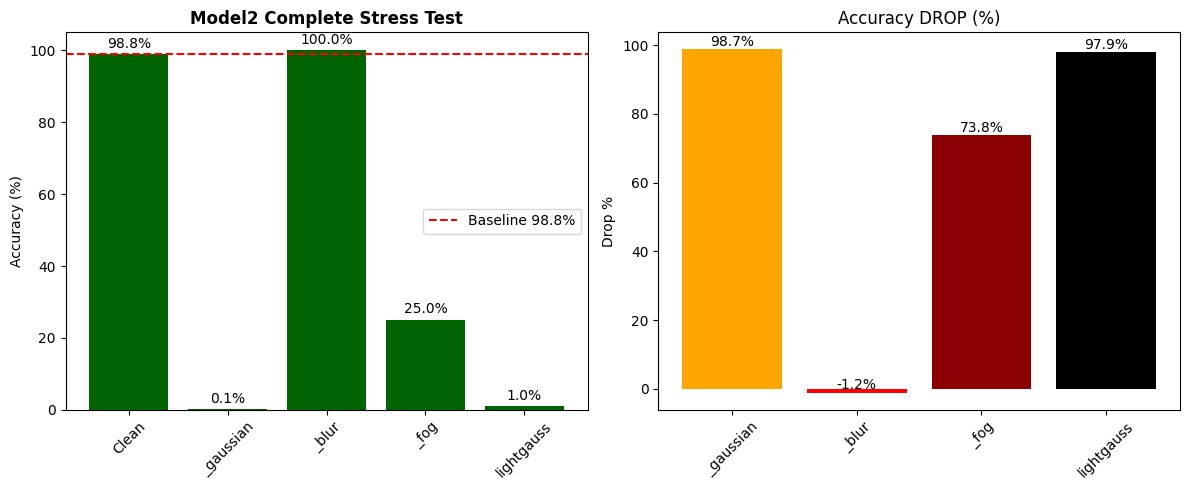


📈 CREATING SEPARATE GRAPHS...

✅ COMPLETE ANALYSIS:
📁 Model2_Complete_StressTest_Results.csv
📁 Model2_Complete_Stress_Analysis.png
📁 4x Model2_[stress]_vs_Baseline.png


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow import keras
import tensorflow as tf
import numpy as np

# Load Model2 (SAME format as Model1)
mhcnnfd_model2 = keras.models.load_model('/content/drive/MyDrive/Model2_Final_2026_v2.h5')
datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255)

baseline_acc = 0.9884  # Same baseline as Model1 (fair comparison)
results = []

# Test original 3 (MHCNNFD_StressTest/)
print("🧪 TESTING Model2 - Original Stress Tests...\n")
stress_base1 = '/content/drive/MyDrive/MHCNNFD_StressTest/'
stress_types1 = ['test_gaussian', 'test_blur', 'test_fog']

for stress_type in stress_types1:
    stress_path = f"{stress_base1}{stress_type}"
    testgen = datagen.flow_from_directory(stress_path, target_size=(256,256),
                                        batch_size=32, class_mode='categorical', shuffle=False)

    loss, acc = mhcnnfd_model2.evaluate(testgen, verbose=1)
    drop_pct = (baseline_acc - acc) * 100

    print(f"{stress_type.upper():<15} | {acc*100:6.1f}% | -{drop_pct:5.1f}%")
    results.append({
        'Stress_Type': stress_type.replace('test',''),
        'Accuracy': acc,
        'Drop_%': drop_pct,
        'Loss': loss
    })

# Test lightgauss (different folder - MHCNNFDStressTest/)
print("\n🧪 TESTING lightgauss (different folder)...")
lightgauss_path = '/content/drive/MyDrive/MHCNNFDStressTest/testlightgauss'
lightgen = datagen.flow_from_directory(lightgauss_path, target_size=(256,256),
                                      batch_size=32, class_mode='categorical', shuffle=False)

loss, acc = mhcnnfd_model2.evaluate(lightgen, verbose=1)
drop_pct = (baseline_acc - acc) * 100
print(f"TESTLIGHTGAUSS    | {acc*100:6.1f}% | -{drop_pct:5.1f}%")
results.append({
    'Stress_Type': 'lightgauss',
    'Accuracy': acc,
    'Drop_%': drop_pct,
    'Loss': loss
})

# Add baseline
results.insert(0, {'Stress_Type': 'Clean', 'Accuracy': baseline_acc, 'Drop_%': 0, 'Loss': 0.029})

# Save results
df_results = pd.DataFrame(results)
df_results.to_csv('/content/drive/MyDrive/Model2_Complete_StressTest_Results.csv', index=False)
print(f"\n💾 SAVED: Model2_Complete_StressTest_Results.csv")

# Display table
print("\n📊 FINAL RESULTS TABLE:")
print(df_results.round(3).to_string(index=False))

# Combined visualization (EXACT Model1 copy)
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
bars = plt.bar(df_results['Stress_Type'], df_results['Accuracy']*100, color='darkgreen')
plt.title('Model2 Complete Stress Test', fontweight='bold')
plt.ylabel('Accuracy (%)')
plt.xticks(rotation=45)
plt.ylim(0, 105)
plt.axhline(y=98.84, color='red', linestyle='--', label='Baseline 98.8%')
plt.legend()
for bar, acc in zip(bars, df_results['Accuracy']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height()+1, f'{acc*100:.1f}%',
             ha='center', va='bottom')

plt.subplot(1,2,2)
drops = df_results['Drop_%'][1:]
plt.bar(df_results['Stress_Type'][1:], drops, color=['orange','red','darkred','black'])
plt.title('Accuracy DROP (%)')
plt.ylabel('Drop %')
plt.xticks(rotation=45)
for i, drop in enumerate(drops):
    plt.text(i, drop+1, f'{drop:.1f}%', ha='center')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Model2_Complete_Stress_Analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# SEPARATE graphs for each stress type
print("\n📈 CREATING SEPARATE GRAPHS...")
for i, row in df_results.iterrows():
    if row['Stress_Type'] != 'Clean':  # Skip baseline
        plt.figure(figsize=(8,6))
        plt.bar(['Baseline 98.8%', row['Stress_Type'].title()], [98.84, row['Accuracy']*100],
                color=['green', 'orange'])
        plt.title(f'Model2: {row["Stress_Type"].title()} vs Baseline')
        plt.ylabel('Accuracy %')
        plt.ylim(0, 105)
        plt.savefig(f'/content/drive/MyDrive/Model2_{row["Stress_Type"]}_vs_Baseline.png',
                    dpi=300, bbox_inches='tight')
        plt.close()

print("\n✅ COMPLETE ANALYSIS:")
print("📁 Model2_Complete_StressTest_Results.csv")
print("📁 Model2_Complete_Stress_Analysis.png")
print("📁 4x Model2_[stress]_vs_Baseline.png")
